In [106]:
# imports
import pysindy as ps
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

import sympy as sp
from sympy.parsing.sympy_parser import parse_expr

from sklearn.metrics import root_mean_squared_error


# Define SINDy model

In [107]:
# diff_method = ps.FiniteDifference()
diff_method = ps.SmoothedFiniteDifference()

# combined feature library
poly_lib = ps.PolynomialLibrary(degree=3)
fourier_lib = ps.FourierLibrary()
feat_lib = poly_lib + fourier_lib

# regression method
optimizer = ps.STLSQ(threshold=0.1)

sindy_model = ps.SINDy(differentiation_method=diff_method, feature_library=feat_lib, optimizer=optimizer)

# Define Model and Get Data

In [108]:
# general simulation function with solve_ivp

def sim_ODE_output(ODE_func, init_cond, timepts, model_params=None):
    """
    model_params, init_cond are dicts
    model_params optional for when 
    timepts is the array of each timepoint
    """
    # unpack param dict values into tuple
    param = None if model_params is None else tuple(model_params.values())
    Y0 = np.array(list(init_cond.values())) if isinstance(init_cond, dict) else np.array(init_cond)

    start_end_times = (timepts[0], timepts[-1])

    sol = scipy.integrate.solve_ivp(fun=ODE_func, t_span=start_end_times, t_eval=timepts, y0=Y0, args=param, method='LSODA')
    return sol

In [109]:
# set up Lotka-Volterra function for solve_ivp

def ODEs_lotka_volterra(t, species, alpha, beta, delta, gamma):
    x, y = species

    # equations
    dx_dt = alpha*x - beta*x*y
    dy_dt = delta*x*y - gamma*y

    return np.array([dx_dt, dy_dt])

lv_params = {
    "alpha": 1.5,
    "beta": 1,
    "delta": 3,
    "gamma": 1,
}

lv_species_init = {
    "x": 2,
    "y": 10,
}

In [110]:
# simulate output
timepts = np.linspace(0, 30, 1001)
# timepts = np.linspace(0, 100, 1001)
# print(timepts)

# do this for randomly selected points
rng = np.random.default_rng(2)
x_range = (0, 30)
y_range = (0, 30)

num_examples = 10

lv_sols = []
lv_outputs = []
for i in range(num_examples):
    species_init_dict = {
        "x": rng.integers(low=x_range[0], high=x_range[1]),
        "y": rng.integers(low=y_range[0], high=y_range[1]),
    }
    lv_sol = sim_ODE_output(ODEs_lotka_volterra, species_init_dict, timepts, model_params=lv_params)
    if lv_sol.success:
        lv_sols.append(lv_sol)
        lv_outputs.append(lv_sol.y)
# print(lv_sol)

print(len(lv_outputs))

10


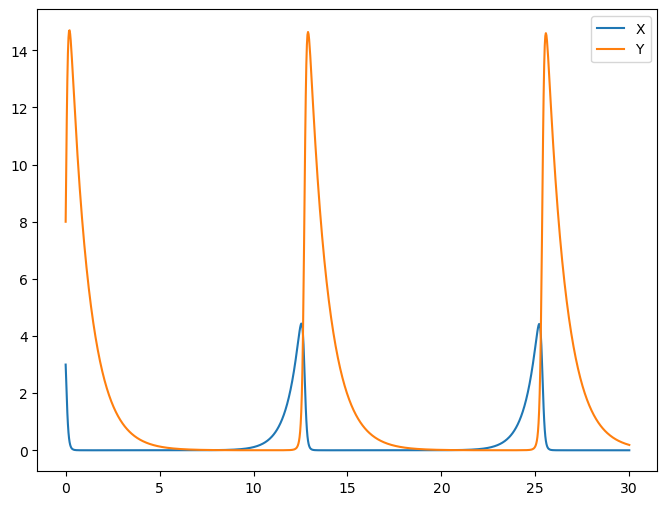

C:\Users\William\AppData\Local\Temp\ipykernel_37652\4072576761.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


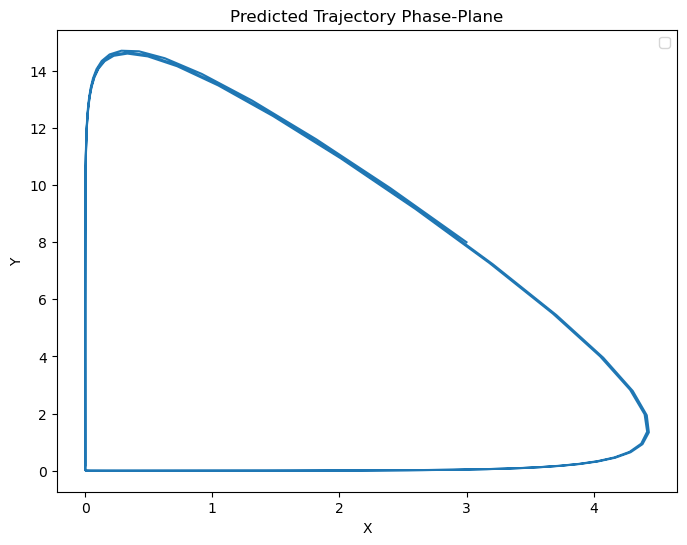

In [111]:
# check
# 0 collapses
lv_sol_x = lv_outputs[1][0]
lv_sol_y = lv_outputs[1][1]
lv_sol_t = lv_sol.t

plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_x, label="X")
plt.plot(lv_sol_t, lv_sol_y, label="Y")
plt.legend()
plt.show()

# plot phase-planes- pred
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_x, lv_sol_y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Predicted Trajectory Phase-Plane")
plt.legend()
plt.show()

# Fit SINDy to the generated data

In [112]:
# first try individual sets of trajectories - a good one

X = lv_outputs[1].T
feat_names = list(lv_species_init.keys())
print(feat_names)

display(sindy_model.fit(X, t=timepts, feature_names=feat_names))
sindy_model.print()

['x', 'y']


,optimizer,STLSQ()
,feature_library,ConcatLibrary...ierLibrary()])
,differentiation_method,SmoothedFiniteDifference()
,libraries,"[PolynomialLibrary(degree=3), FourierLibrary()]"
,threshold,0.1
,alpha,0.05
,max_iter,20
,ridge_kw,None
,normalize_columns,False
,copy_X,True
,initial_guess,None


(x)' = -2.833 1 + -0.682 x +  2.610 x^2 + -0.983 x y + -0.426 x^3 +  1.558 sin(1 x) +  2.837 cos(1 x)
(y)' =  8.073 1 +  6.274 x + -0.978 y + -7.494 x^2 +  2.937 x y +  1.226 x^3 + -4.410 sin(1 x) + -8.128 cos(1 x)


In [113]:
# def sindy_ode(t, y):

print(lv_outputs[1][:, 0])
print([X.T[:, 0]])

start_vals = X.T[:, 0].reshape(1, -1)

dX_dt = sindy_model.predict(X)
dx_dt_pred = dX_dt[:, 0] # first col
dy_dt_pred = dX_dt[:, 1] # second col
print(dX_dt)

[3. 8.]
[array([3., 8.])]
[[-1.90886035e+01  6.26267357e+01]
 [-1.97164351e+01  5.99739376e+01]
 [-1.79277998e+01  5.03758888e+01]
 ...
 [ 4.69728725e-03 -2.48351478e-01]
 [ 4.69874843e-03 -2.42620318e-01]
 [ 4.70027532e-03 -2.37060529e-01]]


[-1.90886035e+01 -1.97164351e+01 -1.79277998e+01 ...  4.69728725e-03
  4.69874843e-03  4.70027532e-03]


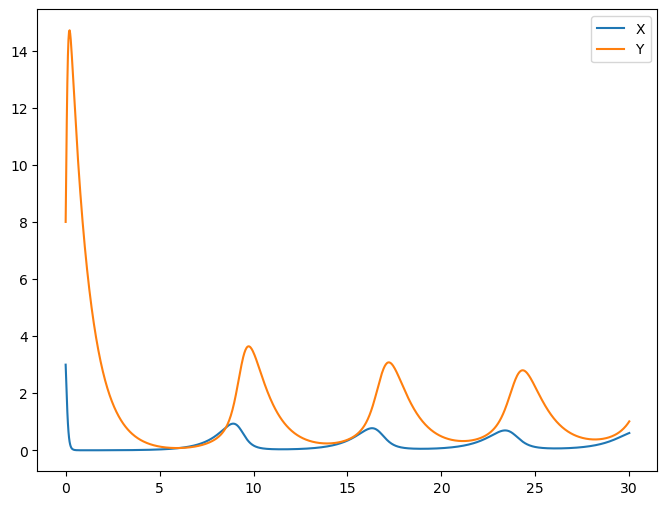

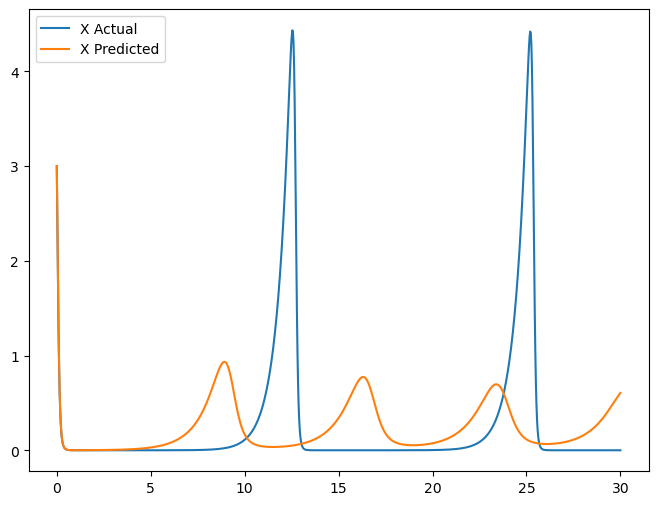

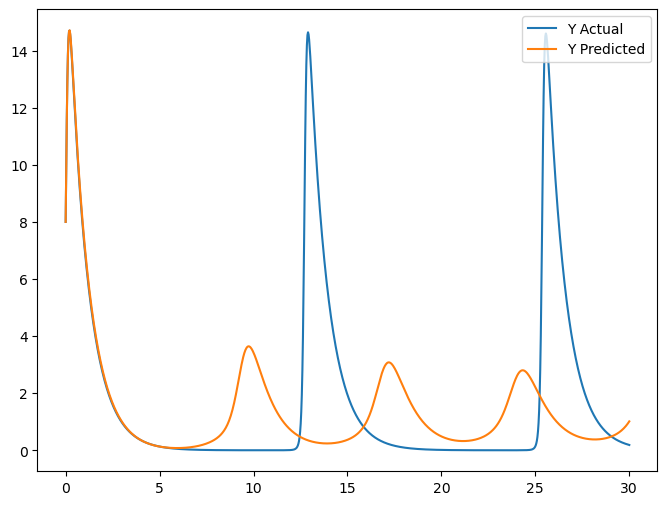

In [114]:
def make_sindy_ODEs(model):
    """
    makes an ODEFunc that I can give to solve_ivp
    t is the time defining length of sim- t_eval
    y is the 2D state vector defining state matrix
    """
    def sindy_pred_ODEs(t, y):
        # print(model.predict(y.reshape(1, -1)).flatten())
        return model.predict(y.reshape(1, -1)).flatten()
    return sindy_pred_ODEs

y0 = X[0, :]

sindy_pred_lv_ODEs = make_sindy_ODEs(sindy_model)
lv_pred_sol = sim_ODE_output(sindy_pred_lv_ODEs, y0, timepts)

print(dx_dt_pred)

# print(dy_dt)

lv_pred_x = lv_pred_sol.y[0]
lv_pred_y = lv_pred_sol.y[1]


# plot the predictions from the data together
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_pred_x, label="X")
plt.plot(lv_sol_t, lv_pred_y, label="Y")
plt.legend()
plt.show()

# plot each predicted trajectory vs. actual trajectory
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_x, label="X Actual")
plt.plot(lv_sol_t, lv_pred_x, label="X Predicted")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_y, label="Y Actual")
plt.plot(lv_sol_t, lv_pred_y, label="Y Predicted")
plt.legend()
plt.show()

# Convert model attributes into symbolic expressions

In [115]:
# sympy-ification code

# parse 
def parse_feature(name, sym_dict):
    """
    parses strings and matches them to symbolic representations
    name: an element of the function library, in string form
    sym_dict: dict of string names of vars to symbols
    will need further work if symbols become more complicated
    """
    # special case- constant
    if name == '1':
        return sp.Integer(1)
    expr = name
    # for k in sym_dict:
    #     # replace string/character k with the symbol in dict
    #     expr = expr.replace(k, f"sym_dict['{k}']")
    #     # exponents
    #     expr = expr.replace("^", "**")
    #     # multiplication
    #     expr = expr.replace(" ", "*")
    # # eval executes the constructed string as python code
    # return eval(expr)
    # alternate version
    # exponents
    expr = expr.replace("^", "**")
    # multiplication
    expr = expr.replace(" ", "*")
    # return using sympy's built-in parser
    return parse_expr(expr, local_dict=sym_dict, evaluate=True)

def sindy_to_sympy(model, var_names=None):
    """
    model: fitted sindy model, containing coefficients and feature names (library functions)
    var_names: list of strings, names of species in the ODE system- must explicitly provide if did not in sindy model.fit
    """
    var_names = var_names if var_names is not None else model.feature_names
    # symbols = sp.symbols(list(var_names))
    symbols = [sp.symbols(v) for v in var_names]
    # dict of species variable names (strings) to sympy symbols
    sym_dict = dict(zip(var_names, symbols))
    
    # get function library terms
    feature_names = model.get_feature_names()
    # get model coefficients
    Xi = model.coefficients().T

    # convert feature name strings into symbolic terms    
    features = [parse_feature(f, sym_dict) for f in feature_names]
    # print("len features", len(features))
    # print("shape Xi", Xi.shape)
    
    # build equations
    equations = []
    # for as many equations as implied by number of columns
    for j in range(Xi.shape[1]):
        eq = sum(Xi[i, j] * features[i] for i in range(len(features)))
        # eq = 0
        # for i in range(len(features)):
        #     eq += Xi[i, j] * features[i]
        equations.append(sp.simplify(eq))
    
    return symbols, equations

# lambdified function wrapper for solve_ivp
def wrap_lambdified_ode(lambdified_func):
    """
    lambdified func is a lambdified function
    """
    def sindy_learned_odes(t, y):
        """
        in format expected by solve_ivp
        y is the vector of states (species)
        """
        return lambdified_func(*y)
    return sindy_learned_odes

In [116]:
# get species names from the dict- repeated line for clarity/explicitness
feat_names = list(lv_species_init.keys())

# initial conditions- first row of state matrix
y0 = X[0, :]

# symbols, equations = sindy_to_sympy(sindy_model, feat_names)

symbols, equations = sindy_to_sympy(sindy_model, feat_names)

print(symbols)
print(equations)

# returns math as lambdified function
sindy_lv_odes_lambdified = sp.lambdify(symbols, equations, modules="numpy")

sindy_lv_odes = wrap_lambdified_ode(sindy_lv_odes_lambdified)
lv_sol_pred = sim_ODE_output(sindy_lv_odes, y0, timepts)



[x, y]
[-0.426376342297313*x**3 + 2.60989802556851*x**2 - 0.983201896161254*x*y - 0.682317529442819*x + 1.55766628005908*sin(x) + 2.83730294685697*cos(x) - 2.83263564579273, 1.22572409032152*x**3 - 7.49360043149336*x**2 + 2.93653886044963*x*y + 6.27377510972238*x - 0.977544221116684*y - 4.40972831153334*sin(x) - 8.12751156944173*cos(x) + 8.07281036511754]


# Plotting and Evaluation Metrics

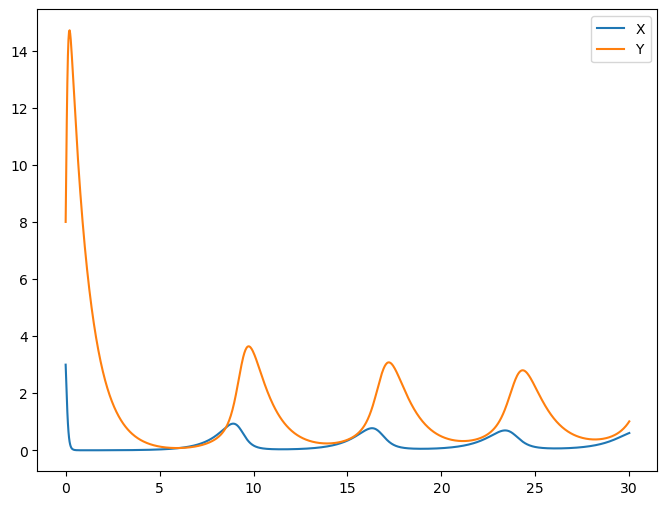

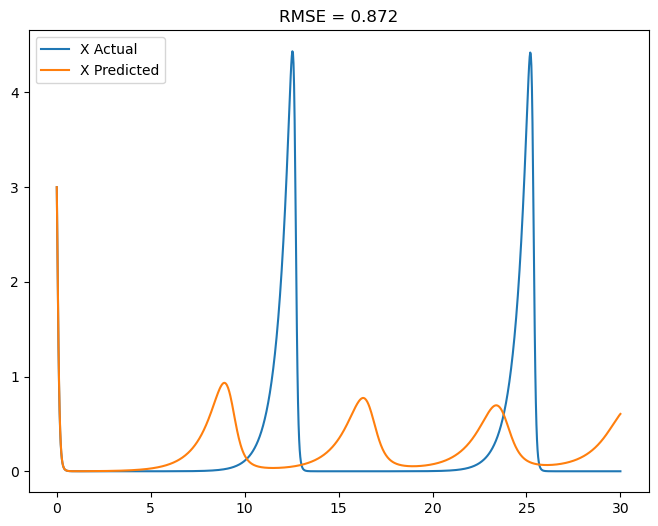

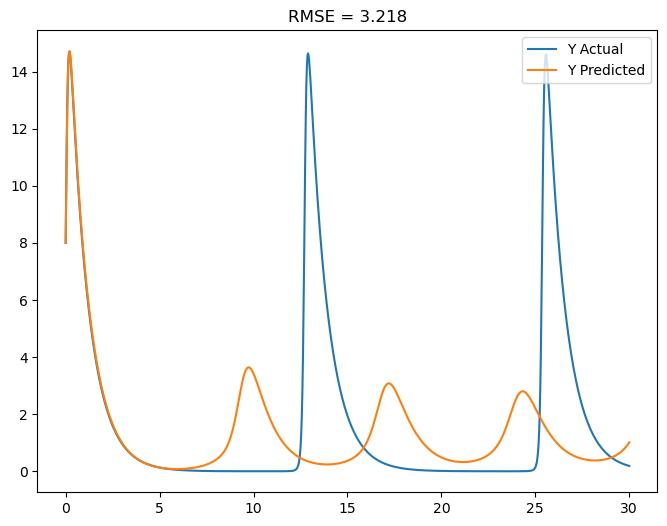

In [117]:
# plot
lv_pred_x = lv_sol_pred.y[0]
lv_pred_y = lv_sol_pred.y[1]


# plot the predictions from the data together
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_pred_x, label="X")
plt.plot(lv_sol_t, lv_pred_y, label="Y")
plt.legend()
plt.show()

# calc rmse- naive because errors propagate and don't really reflect whether behavior follows, just pure error
rmse_x = root_mean_squared_error(lv_sol_x, lv_pred_x)

# plot each predicted trajectory vs. actual trajectory
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_x, label="X Actual")
plt.plot(lv_sol_t, lv_pred_x, label="X Predicted")
plt.title(f"RMSE = {rmse_x:.3f}")
plt.legend()
plt.show()


rmse_y = root_mean_squared_error(lv_sol_y, lv_pred_y)

plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_sol_y, label="Y Actual")
plt.plot(lv_sol_t, lv_pred_y, label="Y Predicted")
plt.title(f"RMSE = {rmse_y:.3f}")
plt.legend()
plt.show()

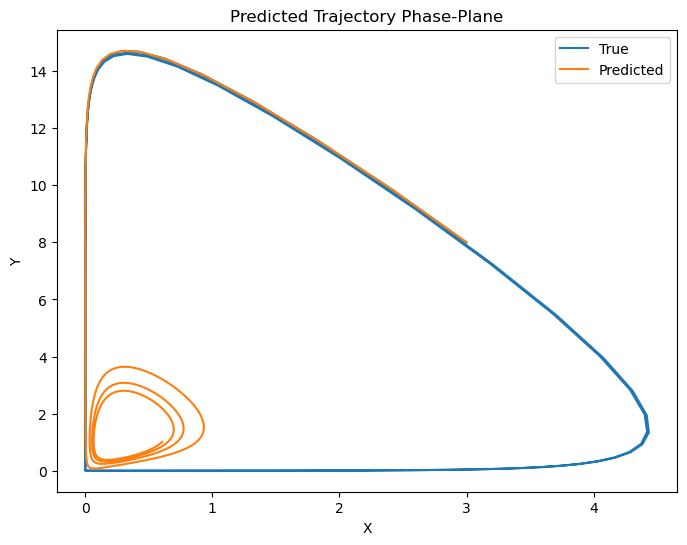

In [118]:
# plot phase-planes- pred
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_x, lv_sol_y, label="True")
plt.plot(lv_pred_x, lv_pred_y, label="Predicted")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Predicted Trajectory Phase-Plane")
plt.legend()
plt.show()

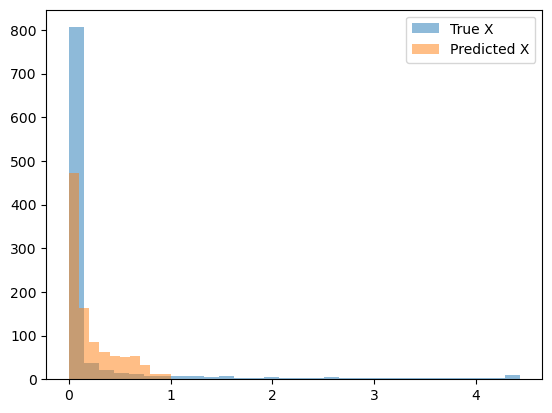

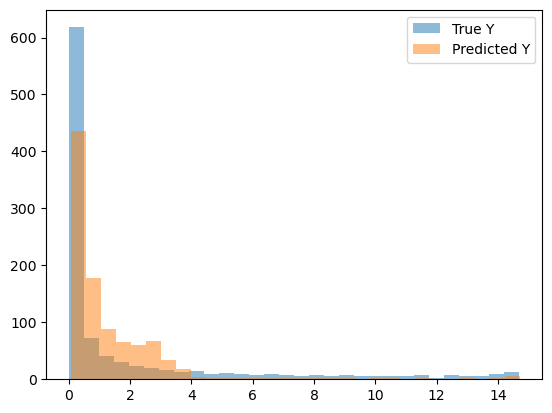

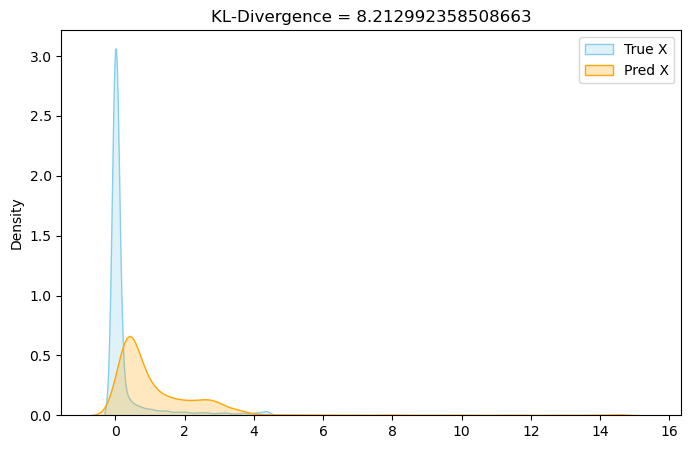

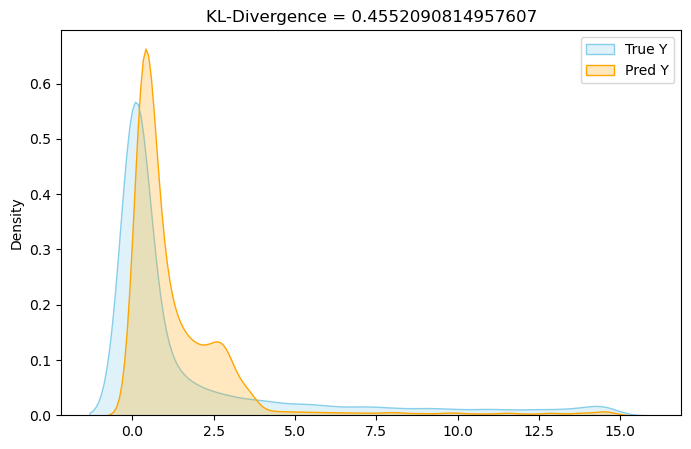

C:\Users\William\AppData\Local\Temp\ipykernel_37652\2930695904.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


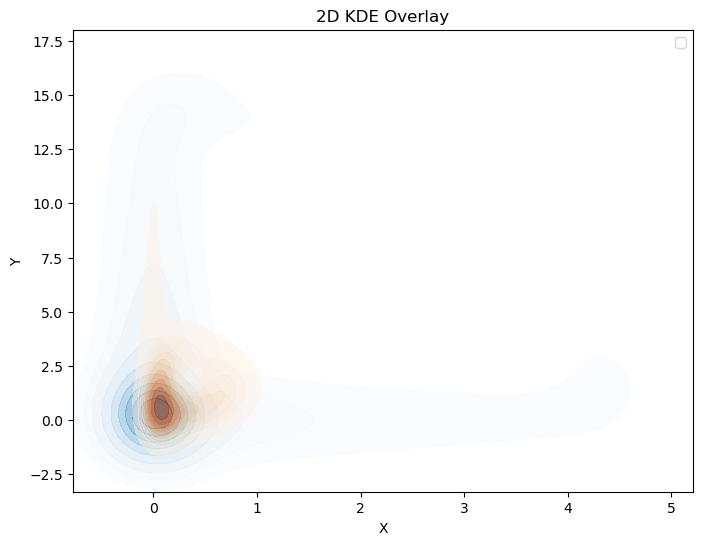

In [ ]:
# plot histogram- distribution of points
# X
plt.hist(lv_sol_x, bins=30, alpha=0.5, label="True X")
plt.hist(lv_pred_x, bins=30, alpha=0.5, label="Predicted X")
plt.legend()
plt.show()

# Y
plt.hist(lv_sol_y, bins=30, alpha=0.5, label="True Y")
plt.hist(lv_pred_y, bins=30, alpha=0.5, label="Predicted Y")
plt.legend()
plt.show()

# kl diveergence of the distrib of x values
pad = 1e-12
hist_true_x, bins_true_x = np.histogram(lv_sol_x, bins=30, density=True)
hist_pred_x, bins_pred_x = np.histogram(lv_pred_x, bins=30, density=True)
hist_true_x_safe, hist_pred_x_safe = hist_true_x + pad, hist_pred_x + pad
kl_x = np.sum(hist_true_x_safe * np.log(hist_true_x_safe/hist_pred_x_safe))
# print(kl_x)

# kde plot showing density
plt.figure(figsize=(8, 5))
sns.kdeplot(data=lv_sol_x, fill=True, color='skyblue', bw_adjust=0.5, label="True X")
sns.kdeplot(data=lv_pred_y, fill=True, color='orange', bw_adjust=0.5, label="Pred X")
plt.title(f"KL-Divergence = {kl_x}")
plt.legend()
plt.show()

# kl diveergence of the distrib of y values
pad = 1e-12
hist_true_y, bins_true_y = np.histogram(lv_sol_y, bins=30, density=True)
hist_pred_y, bins_pred_y = np.histogram(lv_pred_y, bins=30, density=True)
hist_true_y_safe, hist_pred_y_safe = hist_true_y + pad, hist_pred_y + pad
kl_y = np.sum(hist_true_y_safe * np.log(hist_true_y_safe/hist_pred_y_safe))
# print(kl_x)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=lv_sol_y, fill=True, color='skyblue', bw_adjust=0.5, label="True Y")
sns.kdeplot(data=lv_pred_y, fill=True, color='orange', bw_adjust=0.5, label="Pred Y")
plt.title(f"KL-Divergence = {kl_y}")
plt.legend()
plt.show()

# try both species together?
plt.figure(figsize=(8,6))
sns.kdeplot(x=lv_sol_x, y=lv_sol_y, fill=True, cmap='Blues', alpha=0.5, label='True')
sns.kdeplot(x=lv_pred_x, y=lv_pred_y, fill=True, cmap='Oranges', alpha=0.5, label='Pred')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D KDE Overlay")
plt.legend()
plt.show()

# try the thing at the bottom of the evaluation page of their documentation?


# Fit SINDy to all of the generated data

In [132]:
# now try training on multiple trajectories

# give it a list of each trajectory, time by num_species
X_all = [traj.T for traj in lv_outputs if traj is not None]

t_all = [timepts for _ in X_all]
print(len(t_all))

feat_names = list(lv_species_init.keys())
print(feat_names)

display(sindy_model.fit(X_all, t=t_all, feature_names=feat_names))
sindy_model.print()

10
['x', 'y']


,optimizer,STLSQ()
,feature_library,ConcatLibrary...ierLibrary()])
,differentiation_method,SmoothedFiniteDifference()
,libraries,"[PolynomialLibrary(degree=3), FourierLibrary()]"
,threshold,0.1
,alpha,0.05
,max_iter,20
,ridge_kw,None
,normalize_columns,False
,copy_X,True
,initial_guess,None


(x)' = -1950.844 1 +  1.503 x +  643.143 y + -4807.906 x y +  0.238 y^2 +  84.444 x y^2 +  2078.175 sin(1 x) +  1445.977 cos(1 x) +  3219.207 sin(1 y) +  95.161 cos(1 y)
(y)' =  1.199 1 +  1.383 x y + -1.641 sin(1 x) + -5.222 cos(1 x) +  0.918 sin(1 y) +  2.328 cos(1 y)


# Sympy to extract equations and plot

In [135]:
# get species names from the dict- repeated line for clarity/explicitness
feat_names = list(lv_species_init.keys())

# initial conditions- first row of state matrix
y0 = X_all[1][0, :]

# symbols, equations = sindy_to_sympy(sindy_model, feat_names)

symbols, equations = sindy_to_sympy(sindy_model, feat_names)

print(symbols)
print(equations)

# returns math as lambdified function
sindy_lv_odes_lambdified = sp.lambdify(symbols, equations, modules="numpy")

sindy_lv_odes = wrap_lambdified_ode(sindy_lv_odes_lambdified)
lv_sol_pred = sim_ODE_output(sindy_lv_odes, y0, timepts)

[x, y]
[84.4440637522527*x*y**2 - 4807.90586325218*x*y + 1.50303972542378*x + 0.23834639607743*y**2 + 643.143380755663*y + 2078.1747710554*sin(x) + 3219.20678902042*sin(y) + 1445.97674566944*cos(x) + 95.1606199501126*cos(y) - 1950.84400093434, 1.38333321634358*x*y - 1.64106927460079*sin(x) + 0.918139748692245*sin(y) - 5.22173522759049*cos(x) + 2.32772366497457*cos(y) + 1.19915452674119]


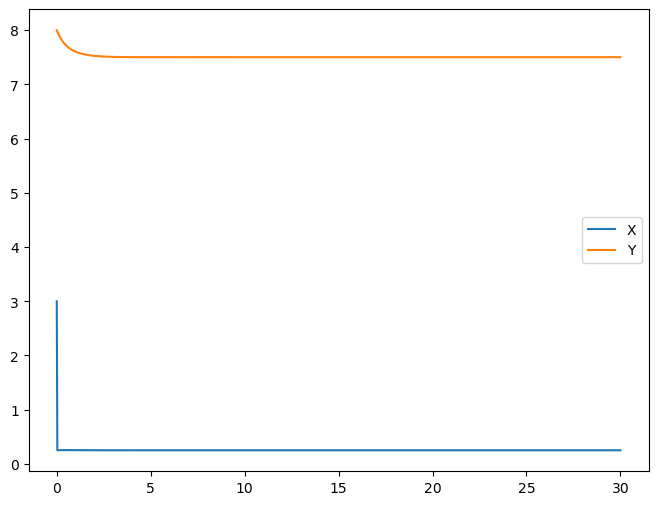

In [136]:
# plot
lv_pred_x = lv_sol_pred.y[0]
lv_pred_y = lv_sol_pred.y[1]


# plot the predictions from the data together
plt.figure(figsize=(8, 6))
plt.plot(lv_sol_t, lv_pred_x, label="X")
plt.plot(lv_sol_t, lv_pred_y, label="Y")
plt.legend()
plt.show()

In [ ]:
# # first try individual sets of trajectories - the messed-up collapse case

# X = lv_outputs[0].T
# feat_names = list(lv_species_init.keys())
# print(feat_names)

# display(sindy_model.fit(X, t=timepts, feature_names=feat_names))
# sindy_model.print()